In [1]:
!pip install librosa scikit-learn matplotlib seaborn tensorflow

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 3.4 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 4.1 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.8 MB/s eta 0:00:08
   - -------------------------------------- 1.3/38.1 MB 4.5 MB/s eta 0:00:09
   - -------------------------------------- 1.3/38.1 MB 4.5 MB/s eta 0:00:09
   - -------------------------------------- 1.6/38.1 MB 1.7 MB/s eta 0:00:21
   - -------------------------------------- 1.6/38.1 MB 1.7 MB/s eta 0:00:21
   -- ------------------------------------- 2.1/38.1 MB 1.6 MB/s eta 0:00:23
   -- -----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Libraries

In [5]:
import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Define Dataset Path

In [2]:
import os
import librosa
import numpy as np

DATASET_PATH = "genres_original"

genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

# Extract MFCC Features from Audio

In [6]:
X = []
y = []

for genre in genres:

    genre_path = os.path.join(DATASET_PATH, genre)

    for file in os.listdir(genre_path):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(genre_path, file)

        try:
            # Load audio
            signal, sr = librosa.load(file_path, duration=30)

            # Extract MFCC
            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

            # Average MFCC values
            mfcc_mean = np.mean(mfcc.T, axis=0)

            X.append(mfcc_mean)
            y.append(genre)

        except Exception as e:
            print("Skipped corrupted file:", file_path)
            continue


X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)
y = np.array(y)

Skipped corrupted file: genres_original\jazz\jazz.00054.wav
Feature shape: (999, 13)
Labels shape: (999,)


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.62


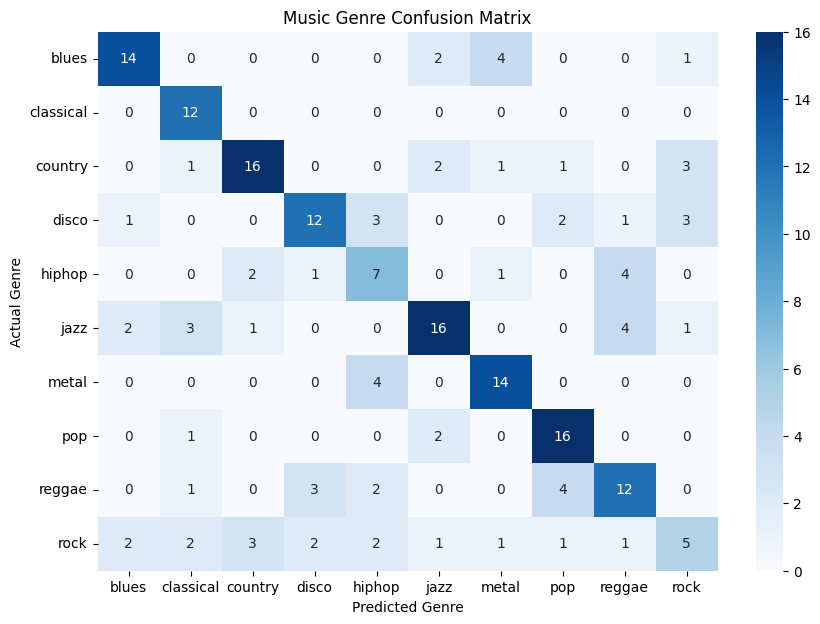

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Music Genre Confusion Matrix")

plt.show()

In [19]:
def predict_genre(file_path):  

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return
    
    try:
        # Load audio
        signal, sr = librosa.load(file_path, duration=30)
    except Exception as e:
        print("Error loading audio:", e)
        return

    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    # Predict genre
    pred = model.predict([mfcc_mean])
    genre = encoder.inverse_transform(pred)

    print("Predicted Genre:", genre[0])


# CALL the function here with your path
predict_genre("Music Genre Project/genres_original/jazz/jazz.00054.wav")

File not found: Music Genre Project/genres_original/jazz/jazz.00054.wav


In [20]:
# Using raw string with backslashes
predict_genre(r"C:\Users\ACG\Documents\Music Genre Project\genres_original\jazz\jazz.00054.wav")

# OR using forward slashes
predict_genre("C:/Users/ACG/Documents/Music Genre Project/genres_original/jazz/jazz.00054.wav")

File not found: C:\Users\ACG\Documents\Music Genre Project\genres_original\jazz\jazz.00054.wav
File not found: C:/Users/ACG/Documents/Music Genre Project/genres_original/jazz/jazz.00054.wav


In [24]:
# Try multiple classifiers
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200),
    'SVM': SVC(kernel='rbf'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")

Random Forest: 0.5850
SVM: 0.4350
KNN: 0.4950
Gradient Boosting: 0.5750


In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_spectrogram(file_path, save_path=None):
    signal, sr = librosa.load(file_path, duration=30)
    
    # Generate mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Resize for CNN input
    from skimage.transform import resize
    mel_spec_resized = resize(mel_spec_db, (128, 128))
    
    return mel_spec_resized

# CNN Model
def create_cnn_model(input_shape=(128, 128, 1), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


Spectrogram shape: (128, 128)
Spectrogram min value: -80.0000
Spectrogram max value: -6.3208


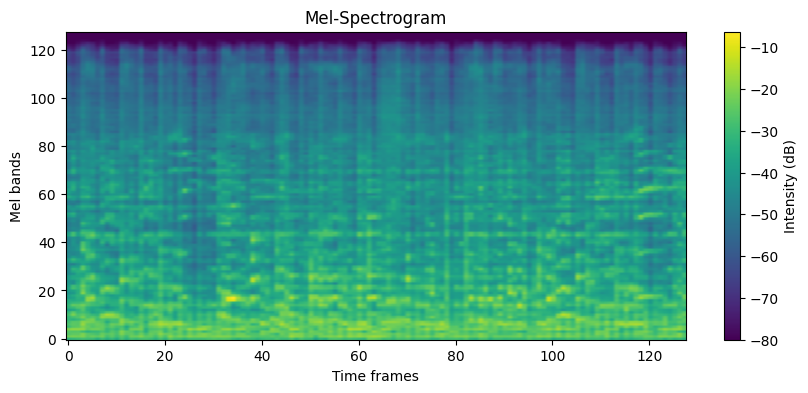

In [31]:
from skimage.transform import resize
import matplotlib.pyplot as plt

# Test with one of your audio files
test_file = "genres_original/blues/blues.00000.wav"  # Adjust path as needed
spectrogram = create_spectrogram(test_file)

print(f"Spectrogram shape: {spectrogram.shape}")
print(f"Spectrogram min value: {spectrogram.min():.4f}")
print(f"Spectrogram max value: {spectrogram.max():.4f}")

# Visualize the spectrogram
plt.figure(figsize=(10, 4))
plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Intensity (dB)')
plt.title('Mel-Spectrogram')
plt.ylabel('Mel bands')
plt.xlabel('Time frames')
plt.show()

In [30]:
!pip install scikit-image

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 524.3 kB/s eta 0:00:24
   - -------------------------------------- 0.5/12.8 MB 524.3 kB/s eta 0:00:24
   - -------------------------------------- 0.5/12.8 MB 524.3 kB/s eta 0:00:24
   -- ------------------------------------- 0.8/12.8 MB 453.5 kB/s eta 0:00:27
   -- ------------------------------------- 0.8/12.8 MB 453.5 kB/s eta 0:00:27
   --- ------------------------------------ 1.0/12.8 MB 503.2 kB/s eta 0:00:24
   --- ------------------------------------ 1.0/12.8 MB 503.2 kB/s eta 0:00:24
   ---- -------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
